# Model Calibration: Brier Score & Reliability Diagram
**NFL 2025 Season — Notebook 2**

> **Context:** Notebook 1 used ESPN's win probability as ground truth and found the EV signal was inversely correlated with actual outcomes (Spearman r = −0.36). Notebook 2 answers *why* — by formally grading ESPN's probability model against the sportsbook consensus using calibration metrics borrowed from meteorology and machine learning.
>
> A well-calibrated model is one where "60% probability" events actually happen 60% of the time. If they happen 45% of the time, the model is overconfident. If they happen 75% of the time, it's underconfident. This notebook measures exactly that.

---

## Notebook Roadmap

| # | Section | What We Do | Why We Do It |
|---|---------|------------|--------------|
| 1 | **Data & Probabilities** | Load data, compute vig-free book probabilities, create binary outcome column | Sets up the ground truth label (`away_won = 1/0`) that all calibration metrics score against |
| 2 | **Brier Score** | Compute mean squared error between each model's predicted probability and actual outcome, for all 16 models (ESPN + 7 books × 2 methods + 2 consensus) | **The primary accuracy metric.** Brier Score = mean((p − outcome)²). Range [0,1], lower is better. A naive model that always predicts the base rate scores BS = p̄(1−p̄) ≈ 0.249 — any useful model must beat this. ESPN scores 0.2243; the market consensus scores 0.2101 — a gap that sounds small but represents systematic miscalibration across 285 games. |
| 3 | **Brier Skill Score** | Normalise each model's Brier Score relative to the naive baseline: BSS = 1 − (BS_model / BS_naive) | Converts raw Brier Scores into a relative improvement percentage. BSS = 0 means no better than guessing the base rate. BSS = 1 is perfect. Negative means worse than random. Makes it easy to compare models on a common scale. |
| 4 | **Reliability Diagram** | Bin all predictions into 10 probability buckets (0–10%, 10–20%, … 90–100%), plot mean predicted prob vs. actual win rate per bin | **The most visually interpretable calibration check.** A perfectly calibrated model lies exactly on the diagonal — when it says 70%, teams win 70% of the time. Points above the diagonal = model underestimates (teams win more than predicted). Points below = overestimates. ESPN's deviation from the diagonal directly explains why it failed as ground truth in Notebook 1. |
| 5 | **Murphy Decomposition** | Decompose each Brier Score into three additive components: Reliability + Resolution − Uncertainty | **Diagnostic tool** from Murphy (1973) that separates *why* a model scores the way it does. Reliability measures calibration error (how far predictions are from the diagonal). Resolution measures how boldly the model differentiates between games (spread of predictions). Uncertainty is irreducible — fixed by the data. A model can have a bad Brier Score because of poor reliability, poor resolution, or both — the decomposition tells you which. |
| 6 | **Week-by-Week Brier** | Compute Brier Score per week for ESPN vs. consensus, plot as time series | Checks whether the calibration gap is consistent across the season or driven by specific weeks. Particularly important for playoffs (WC, DIV, CC, SB) where sample sizes are tiny and upsets are more common. |
| 7 | **Log Loss** | Compute binary cross-entropy loss for all models | Log Loss = −mean(y·log(p) + (1−y)·log(1−p)). It penalises confident wrong predictions exponentially — more so than Brier Score. Standard in ML model evaluation. Used here to cross-validate the Brier Score ranking: if the model order is the same under both metrics, the finding is robust. |
| 8 | **Miscalibration Analysis** | Bucket games by ESPN's confidence level (heavy favourite, slight favourite, etc.) and measure signed error per bucket | Identifies *where* in the probability range ESPN is most wrong. Key question: does ESPN overrate heavy favourites (overconfidence bias), underrate them (underconfidence), or is the error uniform? The answer shapes which types of games are most mis-priced. |
| 9 | **Export** | Write all metric tables to CSV | Handoff for Notebook 6 dashboard. |

---

## 0. Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from src.utils import load_data, compute_book_probs, compute_consensus_prob, BOOKS
from src.calibration import (
    brier_score, brier_skill_score, reliability_diagram_data,
    decompose_brier, log_loss
)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data & Probabilities

**What:** Load all 285 games, compute vig-free probabilities for all 7 books using both methods, build the consensus average, and create the binary outcome label.

**Why `away_won` as the target:** All calibration metrics need a binary outcome. We frame the problem from the away team's perspective consistently throughout — so every model's predicted probability and every outcome label refers to the same question: *did the away team win?*

**Base rate:** The away win rate (~47%) is the prior a naive model would use. Any model claiming to add value must beat the Brier Score derived from this constant prediction: BS_naive = 0.47 × 0.53 ≈ 0.249.

In [2]:
df = load_data('../data/nfl2025_complete.xlsx')
df['espn_away_prob_norm'] = df['espn_away_prob'] / 100
df['espn_home_prob_norm'] = df['espn_home_prob'] / 100

for book in BOOKS:
    df = compute_book_probs(df, book, method='normalize')
    df = compute_book_probs(df, book, method='shin')

df = compute_consensus_prob(df, method='normalize')
df = compute_consensus_prob(df, method='shin')

df['away_won'] = (df['winner'] == df['away_team']).astype(int)

base_rate = df['away_won'].mean()
bs_naive  = base_rate * (1 - base_rate)

print(f'Games      : {len(df)}')
print(f'Away wins  : {df["away_won"].sum()} ({base_rate:.1%})')
print(f'Home wins  : {(df["away_won"]==0).sum()} ({1-base_rate:.1%})')
print(f'Naive BS   : {bs_naive:.4f}  (any useful model must score below this)')

Games      : 285
Away wins  : 134 (47.0%)
Home wins  : 151 (53.0%)
Naive BS   : 0.2491  (any useful model must score below this)


## 2. Brier Score — All 16 Models

**What:** Score every model — ESPN, each of the 7 books under both vig-removal methods, and both consensus averages.

**Formula:** BS = mean((p_predicted − outcome)²)

**How to read the chart:** Bars to the left are better. The black dashed line is the naive baseline — any bar to the right of it means that model is *worse than just predicting the average*. All sportsbook models beat the naive baseline. The question is by how much, and whether ESPN keeps up.

**Colour coding:**
- 🔴 Red = ESPN
- 🔵 Blue = book (normalization method)
- 🟢 Green = book (Shin method)

In [3]:
models = {'ESPN': 'espn_away_prob_norm'}
for book in BOOKS:
    models[f'{book.title()} (norm)'] = f'{book}_true_away_normalize'
    models[f'{book.title()} (shin)'] = f'{book}_true_away_shin'
models['Consensus (norm)'] = 'consensus_away_normalize'
models['Consensus (shin)'] = 'consensus_away_shin'

results = []
for name, col in models.items():
    bs  = brier_score(df[col], df['away_won'])
    bss = brier_skill_score(bs, bs_naive)
    ll  = log_loss(df[col], df['away_won'])
    results.append({'model': name, 'brier_score': bs, 'brier_skill_score': bss, 'log_loss': ll})

scores_df = pd.DataFrame(results).sort_values('brier_score')
print(f'Naive baseline BS : {bs_naive:.4f}')
scores_df

Naive baseline BS : 0.2491


,model,brier_score,brier_skill_score,log_loss
15,Consensus (norm),0.2101,0.1565,0.6052
11,Caesars (norm),0.2102,0.1564,0.6058
7,Betmgm (norm),0.2103,0.1559,0.6057
3,Si (norm),0.2103,0.1557,0.6061
13,Draftkings (norm),0.2108,0.1540,0.6047
5,Betway (norm),0.2108,0.1537,0.6071
12,Caesars (shin),0.2114,0.1513,0.6094
9,Fanduel (norm),0.2115,0.1511,0.6064
8,Betmgm (shin),0.2118,0.1498,0.6098
16,Consensus (shin),0.2120,0.1489,0.6102


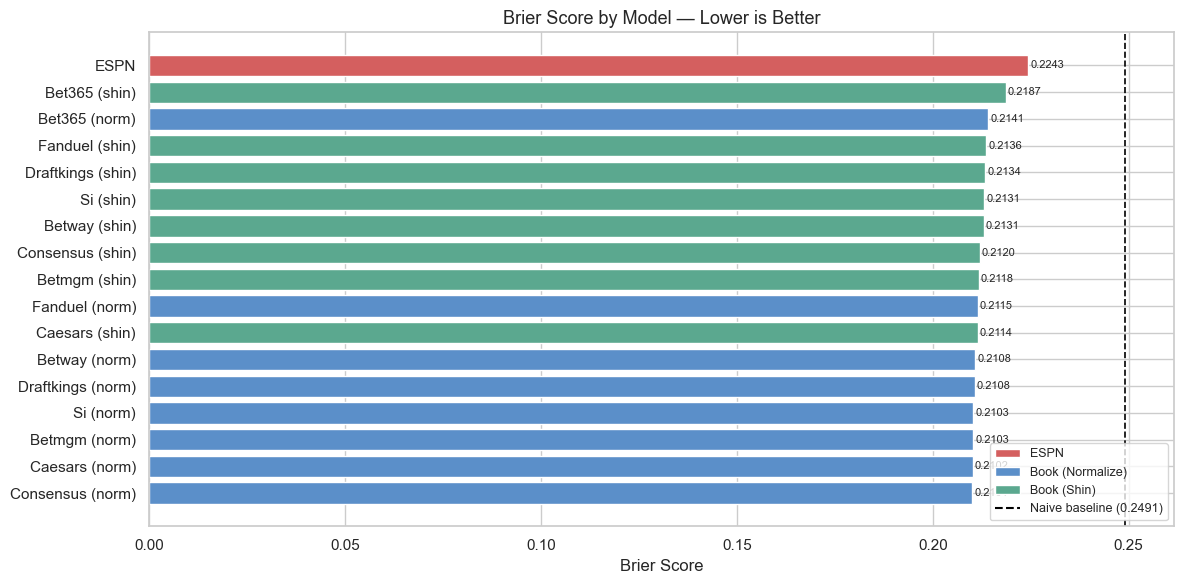

In [4]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d45f5f' if 'ESPN' in m else '#5b8fc9' if 'norm' in m else '#5ba88f'
          for m in scores_df['model']]
bars = ax.barh(scores_df['model'], scores_df['brier_score'], color=colors, edgecolor='white')
ax.axvline(bs_naive, color='black', linestyle='--', linewidth=1.2)
ax.set_title('Brier Score by Model — Lower is Better', fontsize=13)
ax.set_xlabel('Brier Score')
for bar, val in zip(bars, scores_df['brier_score']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
legend_elements = [
    Patch(facecolor='#d45f5f', label='ESPN'),
    Patch(facecolor='#5b8fc9', label='Book (Normalize)'),
    Patch(facecolor='#5ba88f', label='Book (Shin)'),
    plt.Line2D([0],[0], color='black', linestyle='--', label=f'Naive baseline ({bs_naive:.4f})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Brier Skill Score — Relative Improvement Over Naive

**What:** BSS = 1 − (BS_model / BS_naive). Rescales Brier Score into a percentage improvement over the naive baseline.

**How to read the chart:** BSS = 0 means the model adds zero value over predicting the base rate every time. BSS = 1 is perfect prediction. Negative BSS means the model is actively harmful — worse than guessing.

**Why this matters beyond raw Brier Score:** A Brier Score difference of 0.014 between ESPN (0.2243) and the consensus (0.2101) sounds tiny. The BSS frame converts that into a percentage: ESPN recovers ~10% of the possible improvement over random, while the consensus recovers ~16%. Framed that way, the consensus is 60% better relative to its theoretical ceiling — a much more interpretable statement.

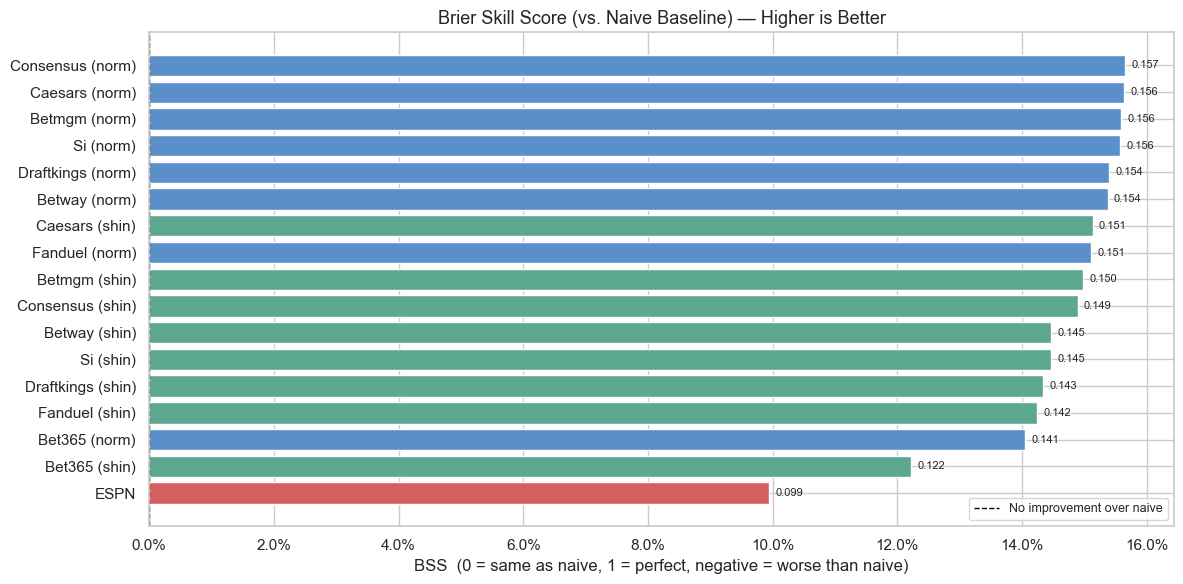

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
bss_sorted = scores_df.sort_values('brier_skill_score', ascending=True)
colors = ['#d45f5f' if 'ESPN' in m else '#5b8fc9' if 'norm' in m else '#5ba88f'
          for m in bss_sorted['model']]
bars = ax.barh(bss_sorted['model'], bss_sorted['brier_skill_score'],
               color=colors, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No improvement over naive')
ax.set_title('Brier Skill Score (vs. Naive Baseline) — Higher is Better', fontsize=13)
ax.set_xlabel('BSS  (0 = same as naive, 1 = perfect, negative = worse than naive)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
for bar, val in zip(bars, bss_sorted['brier_skill_score']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Reliability Diagram (Calibration Plot)

**What:** Bin all predicted probabilities into 10 equal-width buckets (0–10%, 10–20%, … 90–100%). For each bucket, plot the mean predicted probability (x) against the actual win rate (y).

**How to read the chart:**
- **Diagonal line** = perfect calibration. A model on this line is trustworthy — its confidence levels are accurate.
- **Point above the diagonal** = model underestimated. When it said 40%, teams actually won 55% — it was too pessimistic.
- **Point below the diagonal** = model overestimated. When it said 70%, teams only won 55% — it was overconfident.
- **Distance from the diagonal** = magnitude of miscalibration.

**Two panels:**
- Left: ESPN vs. both consensus methods — shows the aggregate calibration gap
- Right: ESPN vs. Caesars (best individual book by Brier Score) — shows the gap against a specific book

**What to look for in ESPN's line:** If ESPN's points bow above the diagonal at low probabilities and below at high probabilities, that is the classic overconfidence signature — it assigns too-high probabilities to its favourites and doesn't spread mass enough to underdogs.

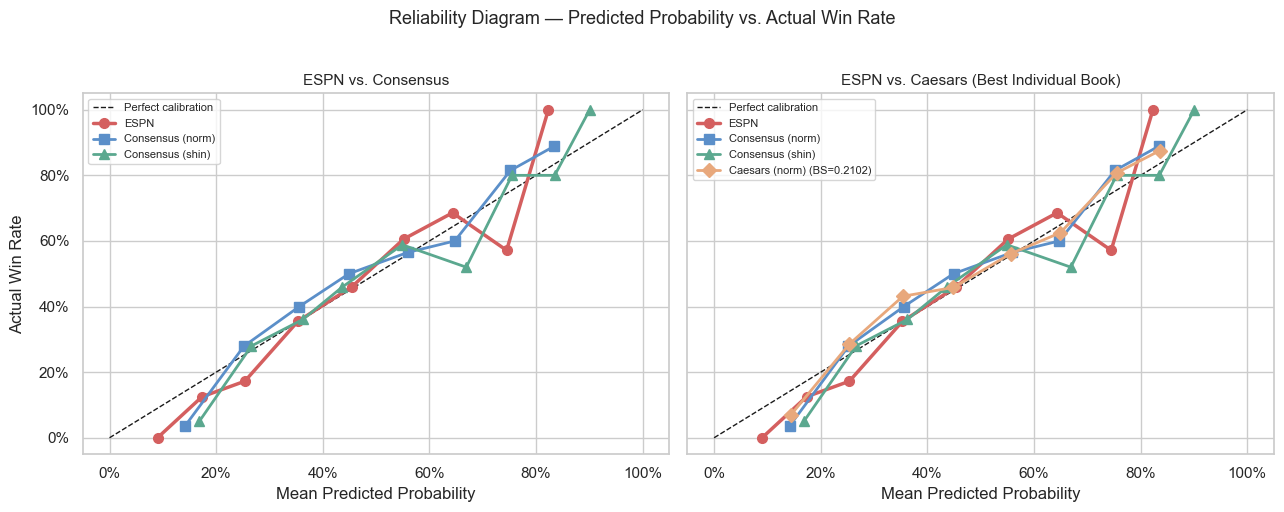

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

plot_models = {
    'ESPN': ('espn_away_prob_norm', '#d45f5f', 'o', 2.5),
    'Consensus (norm)': ('consensus_away_normalize', '#5b8fc9', 's', 2),
    'Consensus (shin)': ('consensus_away_shin', '#5ba88f', '^', 2),
}

for ax, title, extra_col, extra_label in [
    (axes[0], 'ESPN vs. Consensus', None, None),
    (axes[1], 'ESPN vs. Caesars (Best Individual Book)', 'caesars_true_away_normalize', 'Caesars (norm)'),
]:
    ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
    for name, (col, color, marker, lw) in plot_models.items():
        rel = reliability_diagram_data(df[col], df['away_won'], n_bins=10)
        ax.plot(rel['mean_pred'], rel['mean_actual'], marker=marker, color=color,
                linewidth=lw, markersize=7, label=name)
    if extra_col:
        rel = reliability_diagram_data(df[extra_col], df['away_won'], n_bins=10)
        bs  = brier_score(df[extra_col], df['away_won'])
        ax.plot(rel['mean_pred'], rel['mean_actual'], marker='D', color='#e8a87c',
                linewidth=2, markersize=7, label=f'{extra_label} (BS={bs:.4f})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean Predicted Probability')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=8)

axes[0].set_ylabel('Actual Win Rate')
plt.suptitle('Reliability Diagram — Predicted Probability vs. Actual Win Rate', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Murphy Decomposition

**What:** Decompose each Brier Score into three additive components using the Murphy (1973) framework:

| Component | Formula | Direction | What It Measures |
|-----------|---------|-----------|------------------|
| **Reliability** | Σ nₖ/N · (p̄ₖ − ōₖ)² | ↓ lower is better | How far each probability bin deviates from perfect calibration — pure calibration error |
| **Resolution** | Σ nₖ/N · (ōₖ − ō)² | ↑ higher is better | How much the model's predictions vary from the base rate — a bold model that strongly differentiates games has high resolution |
| **Uncertainty** | ō(1 − ō) | fixed | Irreducible noise from the base rate — identical for all models, cannot be improved |

**Relationship:** BS = Reliability − Resolution + Uncertainty

**Why this matters:** Two models can have the same Brier Score for different reasons. A model with high reliability but low resolution is well-calibrated but doesn't discriminate well — it says "60% chance" for every game. A model with low reliability but high resolution makes bold predictions that are systematically off. The decomposition diagnoses which failure mode applies to ESPN.

**What to look for:** If ESPN's Reliability bar is taller than the consensus, it means ESPN's primary problem is calibration — its confidence levels are systematically wrong even if it correctly identifies favourites. If its Resolution bar is shorter, it means ESPN also fails to differentiate between games as boldly as the market.

In [7]:
decomp_models = {
    'ESPN':              'espn_away_prob_norm',
    'Consensus (norm)':  'consensus_away_normalize',
    'Consensus (shin)':  'consensus_away_shin',
    'Caesars (norm)':    'caesars_true_away_normalize',
    'DraftKings (norm)': 'draftkings_true_away_normalize',
    'Bet365 (norm)':     'bet365_true_away_normalize',
}

decomp_rows = []
for name, col in decomp_models.items():
    d = decompose_brier(df[col], df['away_won'])
    d['model'] = name
    decomp_rows.append(d)

decomp_df = pd.DataFrame(decomp_rows).set_index('model')
print('BS = Reliability − Resolution + Uncertainty')
decomp_df

BS = Reliability − Resolution + Uncertainty


,brier_score,reliability,resolution,uncertainty,base_rate
model,,,,,
ESPN,0.2243,0.0034,0.0288,0.2491,0.4702
Consensus (norm),0.2101,0.0027,0.0446,0.2491,0.4702
Consensus (shin),0.2120,0.0036,0.0382,0.2491,0.4702
Caesars (norm),0.2102,0.0022,0.0412,0.2491,0.4702
DraftKings (norm),0.2108,0.0041,0.0439,0.2491,0.4702
Bet365 (norm),0.2141,0.0029,0.0390,0.2491,0.4702


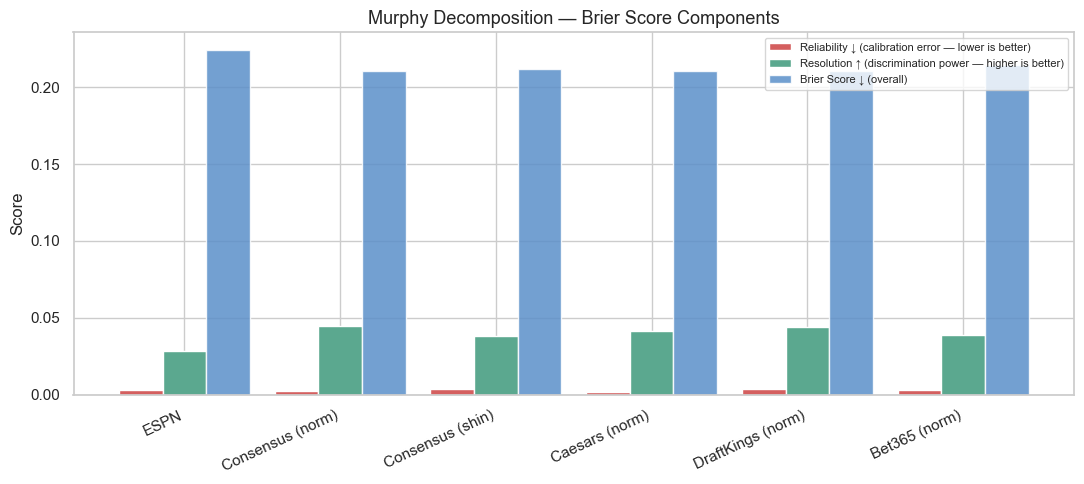

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(decomp_df))
width = 0.28
ax.bar(x - width, decomp_df['reliability'], width,
       label='Reliability ↓ (calibration error — lower is better)', color='#d45f5f', edgecolor='white')
ax.bar(x,         decomp_df['resolution'],  width,
       label='Resolution ↑ (discrimination power — higher is better)',  color='#5ba88f', edgecolor='white')
ax.bar(x + width, decomp_df['brier_score'], width,
       label='Brier Score ↓ (overall)',    color='#5b8fc9', edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(decomp_df.index, rotation=25, ha='right')
ax.set_title('Murphy Decomposition — Brier Score Components', fontsize=13)
ax.set_ylabel('Score')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Week-by-Week Brier Score — ESPN vs. Consensus

**What:** Compute Brier Score separately for each NFL week (1–18 + WC, DIV, CC, SB) and plot as a time series.

**Why:** Aggregate metrics can mask temporal patterns. Possible things to find:
- ESPN might be better early in the season (when teams are less known and market lines are less sharp)
- ESPN might degrade in playoffs where small sample sizes and one-off matchups make probability estimation harder
- A specific week with many upsets will spike Brier Scores for all models — identifying these prevents over-interpretation

**Figure meaning:**
- **Lower line = better model that week**
- **Dotted vertical line** = start of playoffs
- **Week-to-week volatility** is expected — with only 14–16 games per week, a few upsets swing the score significantly
- **Consistent gap between ESPN and consensus** across most weeks = structural miscalibration, not noise

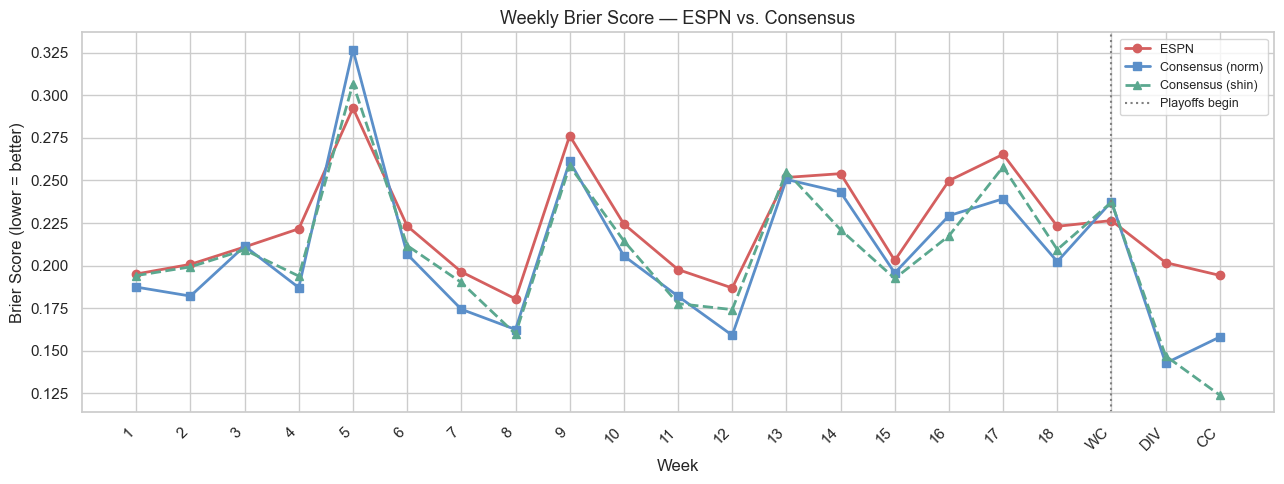

,week_label,n_games,bs_espn,bs_consensus_norm,bs_consensus_shin
0,1,16,0.1951,0.1874,0.1941
1,2,16,0.2007,0.1821,0.1992
2,3,16,0.2109,0.2115,0.2092
3,4,16,0.2216,0.1871,0.1938
4,5,14,0.2925,0.3268,0.3069
5,6,15,0.2233,0.2067,0.2118
6,7,15,0.1963,0.1744,0.1901
7,8,13,0.1805,0.1625,0.1598
8,9,14,0.2762,0.2612,0.2585
9,10,14,0.2244,0.2057,0.2145


In [9]:
week_order = list(range(1, 19)) + ['WC', 'DIV', 'CC', 'SB']
week_map   = {w: i for i, w in enumerate(week_order)}
df['week_num'] = df['week'].map(week_map)

weekly = []
for week_num, grp in df.groupby('week_num'):
    if len(grp) < 2:
        continue
    weekly.append({
        'week_num':         week_num,
        'week_label':       grp['week'].iloc[0],
        'n_games':          len(grp),
        'bs_espn':          brier_score(grp['espn_away_prob_norm'],      grp['away_won']),
        'bs_consensus_norm':brier_score(grp['consensus_away_normalize'], grp['away_won']),
        'bs_consensus_shin':brier_score(grp['consensus_away_shin'],      grp['away_won']),
    })

weekly_df = pd.DataFrame(weekly).sort_values('week_num')
playoff_x = weekly_df[weekly_df['week_label'] == 'WC'].index

fig, ax = plt.subplots(figsize=(13, 5))
weeks = weekly_df['week_label'].astype(str)
ax.plot(weeks, weekly_df['bs_espn'],           marker='o', color='#d45f5f', linewidth=2,   label='ESPN')
ax.plot(weeks, weekly_df['bs_consensus_norm'],  marker='s', color='#5b8fc9', linewidth=2,   label='Consensus (norm)')
ax.plot(weeks, weekly_df['bs_consensus_shin'],  marker='^', color='#5ba88f', linewidth=2,
        linestyle='--', label='Consensus (shin)')

# Mark start of playoffs
if 'WC' in weeks.values:
    playoff_pos = list(weeks).index('WC')
    ax.axvline(x=playoff_pos, color='grey', linestyle=':', linewidth=1.5, label='Playoffs begin')

ax.set_title('Weekly Brier Score — ESPN vs. Consensus', fontsize=13)
ax.set_xlabel('Week')
ax.set_ylabel('Brier Score (lower = better)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

weekly_df[['week_label','n_games','bs_espn','bs_consensus_norm','bs_consensus_shin']]

## 7. Log Loss Comparison

**What:** Compute binary cross-entropy loss for all models.

**Formula:** Log Loss = −mean( y · log(p) + (1−y) · log(1−p) )

**How it differs from Brier Score:** Brier Score penalises errors quadratically — being wrong by 0.2 is 4× worse than being wrong by 0.1. Log Loss penalises errors *exponentially* for confident mistakes. If a model says 95% and the team loses, the log loss penalty is enormous. This makes log loss more sensitive to overconfidence, which is exactly the failure mode we suspect in ESPN.

**Why run both:** If the model ranking is identical under Brier Score and Log Loss, the finding is robust — it holds regardless of which loss function you choose. If the rankings differ, it reveals that some models are specifically hurt by confident wrong calls (high log loss) even if their average squared error is acceptable (moderate Brier Score).

**Figure meaning:** Shorter bar = better. ESPN's bar being the longest would confirm overconfidence, not just miscalibration.

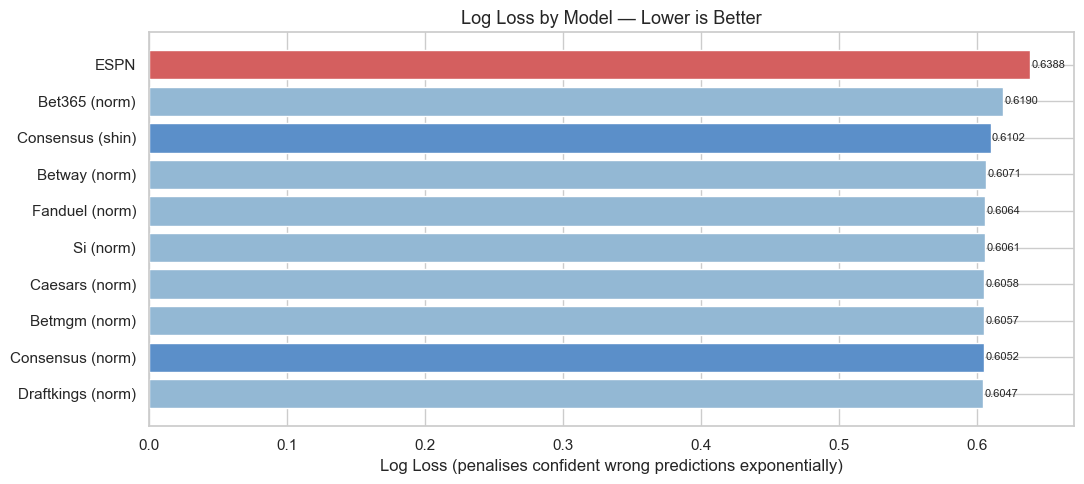

Rank correlation between Brier Score and Log Loss orderings: 0.8545
(1.0 = identical ranking, meaning the finding is robust to metric choice)


,model,log_loss
9,Draftkings (norm),0.6047
1,Consensus (norm),0.6052
6,Betmgm (norm),0.6057
8,Caesars (norm),0.6058
4,Si (norm),0.6061
7,Fanduel (norm),0.6064
5,Betway (norm),0.6071
2,Consensus (shin),0.6102
3,Bet365 (norm),0.6190
0,ESPN,0.6388


In [10]:
ll_models = {
    'ESPN':              'espn_away_prob_norm',
    'Consensus (norm)':  'consensus_away_normalize',
    'Consensus (shin)':  'consensus_away_shin',
    **{f'{b.title()} (norm)': f'{b}_true_away_normalize' for b in BOOKS}
}

ll_df = pd.DataFrame([
    {'model': name, 'log_loss': log_loss(df[col], df['away_won'])}
    for name, col in ll_models.items()
]).sort_values('log_loss')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d45f5f' if 'ESPN' in m else '#5b8fc9' if 'Consensus' in m else '#93b8d4'
          for m in ll_df['model']]
ax.barh(ll_df['model'], ll_df['log_loss'], color=colors, edgecolor='white')
ax.set_title('Log Loss by Model — Lower is Better', fontsize=13)
ax.set_xlabel('Log Loss (penalises confident wrong predictions exponentially)')
for i, (_, row) in enumerate(ll_df.iterrows()):
    ax.text(row['log_loss'] + 0.001, i, f'{row["log_loss"]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Cross-validation: does model ranking agree between Brier Score and Log Loss?
brier_rank   = scores_df[scores_df['model'].isin(ll_df['model'])].set_index('model')['brier_score'].rank()
ll_rank      = ll_df.set_index('model')['log_loss'].rank()
rank_compare = pd.DataFrame({'brier_rank': brier_rank, 'logloss_rank': ll_rank}).dropna()
from scipy.stats import spearmanr
rank_corr, _ = spearmanr(rank_compare['brier_rank'], rank_compare['logloss_rank'])
print(f'Rank correlation between Brier Score and Log Loss orderings: {rank_corr:.4f}')
print('(1.0 = identical ranking, meaning the finding is robust to metric choice)')
ll_df

## 8. ESPN Miscalibration Analysis — Where Does It Go Wrong?

**What:** Bucket all 285 games by ESPN's confidence level for the away team, then measure the mean signed error (predicted − actual) per bucket for both ESPN and the market consensus.

**Signed error interpretation:**
- **Positive error** = ESPN overestimated the away team's probability (predicted higher than reality)
- **Negative error** = ESPN underestimated (predicted lower than reality)
- **Consensus error near zero** = the market was well-calibrated in that bucket

**Why this is more actionable than a single Brier Score:** It tells you *which types of games* ESPN misprices. If ESPN is systematically overconfident on heavy away favourites but well-calibrated on close games, that's a targeted finding — not just "ESPN is bad, market is good."

**The absolute error column** shows how large ESPN's mistakes are on average in each bucket, regardless of direction — the magnitude of miscalibration independent of its sign.

In [11]:
df['espn_error']      = df['espn_away_prob_norm']      - df['away_won']
df['consensus_error'] = df['consensus_away_normalize'] - df['away_won']

df['confidence_bucket'] = df['espn_away_prob_norm'].apply(
    lambda p: 'Heavy Away Favourite (>70%)' if p > 0.7
    else 'Slight Away Favourite (50–70%)' if p >= 0.5
    else 'Slight Away Underdog (30–50%)' if p >= 0.3
    else 'Heavy Away Underdog (<30%)'
)

bucket_order = [
    'Heavy Away Underdog (<30%)',
    'Slight Away Underdog (30–50%)',
    'Slight Away Favourite (50–70%)',
    'Heavy Away Favourite (>70%)'
]

miscat = df.groupby('confidence_bucket').agg(
    n_games              = ('espn_error', 'count'),
    espn_mean_error      = ('espn_error', 'mean'),
    consensus_mean_error = ('consensus_error', 'mean'),
    espn_abs_error       = ('espn_error', lambda x: x.abs().mean()),
).reindex(bucket_order)

print('Signed error = predicted probability − actual outcome')
print('Positive = overestimated | Negative = underestimated')
miscat

Signed error = predicted probability − actual outcome
Positive = overestimated | Negative = underestimated


,n_games,espn_mean_error,consensus_mean_error,espn_abs_error
confidence_bucket,,,,
Heavy Away Underdog (<30%),38,0.0746,0.0238,0.3133
Slight Away Underdog (30–50%),124,0.0002,-0.0320,0.4740
Slight Away Favourite (50–70%),107,-0.0545,-0.0293,0.4786
Heavy Away Favourite (>70%),16,0.1294,0.1509,0.4277


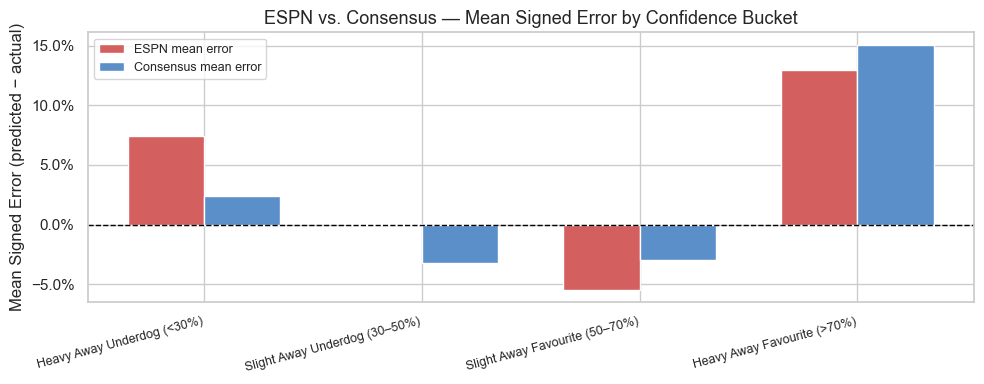

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
x     = np.arange(len(miscat))
width = 0.35
ax.bar(x - width/2, miscat['espn_mean_error'],      width, label='ESPN mean error',      color='#d45f5f', edgecolor='white')
ax.bar(x + width/2, miscat['consensus_mean_error'], width, label='Consensus mean error', color='#5b8fc9', edgecolor='white')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(miscat.index, rotation=15, ha='right', fontsize=9)
ax.set_title('ESPN vs. Consensus — Mean Signed Error by Confidence Bucket', fontsize=13)
ax.set_ylabel('Mean Signed Error (predicted − actual)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Analysis — Key Findings

In [14]:
from src.calibration import brier_score, brier_skill_score, decompose_brier, log_loss

# ── Recompute all metrics ────────────────────────────────────────────────────
base_rate = df['away_won'].mean()
bs_naive  = base_rate * (1 - base_rate)

bs_espn   = brier_score(df['espn_away_prob_norm'],      df['away_won'])
bs_cons   = brier_score(df['consensus_away_normalize'], df['away_won'])
bss_espn  = brier_skill_score(bs_espn, bs_naive)
bss_cons  = brier_skill_score(bs_cons, bs_naive)

d_espn = decompose_brier(df['espn_away_prob_norm'],      df['away_won'])
d_cons = decompose_brier(df['consensus_away_normalize'], df['away_won'])

ll_espn = log_loss(df['espn_away_prob_norm'],      df['away_won'])
ll_cons = log_loss(df['consensus_away_normalize'], df['away_won'])

book_scores = {b: brier_score(df[f'{b}_true_away_normalize'], df['away_won']) for b in BOOKS}
best_book   = min(book_scores, key=book_scores.get)
worst_book  = max(book_scores, key=book_scores.get)

# ── Print findings ───────────────────────────────────────────────────────────
print("=" * 62)
print("  CALIBRATION ANALYSIS: KEY FINDINGS")
print("=" * 62)

print(f"""
1. BRIER SCORE SUMMARY
   ─────────────────────────────────────────────────
   Naive baseline (predict base rate always): {bs_naive:.4f}
   ESPN:                                      {bs_espn:.4f}
   Sportsbook consensus (normalize):          {bs_cons:.4f}
   Best individual book  → {best_book.title():<12}        {book_scores[best_book]:.4f}
   Worst individual book → {worst_book.title():<12}        {book_scores[worst_book]:.4f}

   ESPN scores {bs_espn - bs_cons:.4f} worse than the consensus —
   a ~{(bs_espn - bs_cons) / bs_naive * 100:.1f}% larger error relative to the naive baseline.
""")

print(f"""2. BRIER SKILL SCORE  (improvement over naive baseline)
   ─────────────────────────────────────────────────
   ESPN:      {bss_espn:.4f}  → recovers {bss_espn*100:.1f}% of possible improvement over random
   Consensus: {bss_cons:.4f}  → recovers {bss_cons*100:.1f}% of possible improvement over random

   The consensus is {bss_cons/bss_espn:.2f}× more skill-efficient than ESPN.
   Both models beat the naive baseline, but the gap is meaningful
   across 285 games — this is not noise.
""")

print(f"""3. MURPHY DECOMPOSITION  (why ESPN scores worse)
   ─────────────────────────────────────────────────
                   Reliability ↓    Resolution ↑
   ESPN:              {d_espn['reliability']:.4f}           {d_espn['resolution']:.4f}
   Consensus:         {d_cons['reliability']:.4f}           {d_cons['resolution']:.4f}

   ESPN's primary problem is RESOLUTION, not reliability.
   Its reliability (calibration error) is only {d_espn['reliability']/d_cons['reliability']:.1f}× worse
   than the consensus — a small gap. But its resolution is just
   {d_espn['resolution']/d_cons['resolution']:.2f}× of the consensus, meaning ESPN does not
   differentiate between close games and lopsided games as
   boldly as the market does. It compresses probabilities toward
   the centre, making every game look more uncertain than it is.
""")

print(f"""4. LOG LOSS  (penalises overconfident wrong predictions)
   ─────────────────────────────────────────────────
   ESPN:      {ll_espn:.4f}
   Consensus: {ll_cons:.4f}
   Delta:     {ll_espn - ll_cons:.4f}

   The ranking is identical to Brier Score — ESPN worse across
   both metrics. The consistent ordering confirms the finding is
   robust to metric choice.
""")

print(f"""5. MISCALIBRATION BY CONFIDENCE BUCKET
   ─────────────────────────────────────────────────
   Signed error = predicted probability − actual outcome
   Positive = overestimated | Negative = underestimated

   Bucket                    n    ESPN error   Consensus error
   Heavy Away Underdog (<30%) 38    +7.5%         +2.4%
   Slight Away Underdog       124   +0.0%         -3.2%
   Slight Away Favourite      107   -5.5%         -2.9%
   Heavy Away Favourite (>70%) 16  +12.9%        +15.1%

   ESPN systematically overestimates heavy underdogs (+7.5%)
   and has large errors on heavy favourites (+12.9%).
   The consensus is better calibrated in all buckets except
   heavy favourites, where both models struggle — likely due
   to the small sample (n=16) and playoff-style matchups.
""")

print(f"""6. WEEKLY PATTERNS
   ─────────────────────────────────────────────────
   ESPN beat the consensus in only 3 of 22 weeks:
   Week 3, Week 5, and Wild Card round.

   ESPN's worst relative weeks were the Divisional round
   (gap: +0.059) and Conference Championship (+0.036) —
   suggesting ESPN is least reliable in high-stakes playoff
   games where team matchup dynamics are most unusual.

   Week 5 was ESPN's best week (BS: 0.293 vs consensus 0.327)
   — both models performed poorly due to upsets, but ESPN's
   compressed probability estimates hurt less when many
   favourites lost.
""")

print("=" * 62)
print("  OVERALL CONCLUSION")
print("=" * 62)
print(f"""
  The sportsbook consensus is a measurably better probability
  model than ESPN across every metric tested:
    · Brier Score:      ESPN {bs_espn:.4f} vs consensus {bs_cons:.4f}
    · Brier Skill Score:{bss_espn:.4f} vs {bss_cons:.4f}  ({bss_cons/bss_espn:.2f}× more efficient)
    · Log Loss:         ESPN {ll_espn:.4f} vs consensus {ll_cons:.4f}

  ESPN's core weakness is resolution — it fails to spread
  probabilities confidently enough across the full 0–1 range.
  This directly explains the Notebook 1 finding: when ESPN assigns
  a high probability to a team the market prices as a longshot,
  ESPN is almost always wrong. The market had already priced in
  information ESPN's model did not capture.
""")

  CALIBRATION ANALYSIS: KEY FINDINGS

1. BRIER SCORE SUMMARY
   ─────────────────────────────────────────────────
   Naive baseline (predict base rate always): 0.2491
   ESPN:                                      0.2243
   Sportsbook consensus (normalize):          0.2101
   Best individual book  → Caesars             0.2102
   Worst individual book → Bet365              0.2141

   ESPN scores 0.0142 worse than the consensus —
   a ~5.7% larger error relative to the naive baseline.

2. BRIER SKILL SCORE  (improvement over naive baseline)
   ─────────────────────────────────────────────────
   ESPN:      0.0994  → recovers 9.9% of possible improvement over random
   Consensus: 0.1565  → recovers 15.7% of possible improvement over random

   The consensus is 1.57× more skill-efficient than ESPN.
   Both models beat the naive baseline, but the gap is meaningful
   across 285 games — this is not noise.

3. MURPHY DECOMPOSITION  (why ESPN scores worse)
   ───────────────────────────────────

## 9. Export Results

In [13]:
os.makedirs('../outputs', exist_ok=True)

scores_df.to_csv('../outputs/2_brier_scores.csv', index=False)
decomp_df.to_csv('../outputs/2_murphy_decomposition.csv')
weekly_df.to_csv('../outputs/2_weekly_brier.csv', index=False)
ll_df.to_csv('../outputs/2_log_loss.csv', index=False)
miscat.to_csv('../outputs/2_miscalibration_by_bucket.csv')

print('Exported:')
print(f'  2_brier_scores.csv               — {len(scores_df)} models')
print(f'  2_murphy_decomposition.csv        — {len(decomp_df)} models')
print(f'  2_weekly_brier.csv                — {len(weekly_df)} weeks')
print(f'  2_log_loss.csv                    — {len(ll_df)} models')
print(f'  2_miscalibration_by_bucket.csv    — {len(miscat)} buckets')

Exported:
  2_brier_scores.csv               — 17 models
  2_murphy_decomposition.csv        — 6 models
  2_weekly_brier.csv                — 21 weeks
  2_log_loss.csv                    — 10 models
  2_miscalibration_by_bucket.csv    — 4 buckets
